Import relevant libraries and import the file using a relative path.
Then Split the data into test and training. We use a specific seed as our random state so that we get the same result every time.

## Imports
- **pandas** is a library for data manipulation. We will use the pandas dataframe as it can easily be turned into PyTorch
- **pathlib** a smart little library used to make relative paths. This way we can have a path that is the same for everyone.
- **torch** The Pytorch library.
- **tranformers** we import AutoConfig and AutoModel from the HugginFace tranformer module. These are used to get the configuration from one of HugginFaces models, and then we create a model from that config using the AutoModel function.
- **train_test_split** this is used to split data into training and testing.

In [1]:
# Data manipulation and visualization libraries
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Machine learning libraries
import torch 
import torch.nn as nn #neural network module
import torch.nn.functional as F #functional module contains functions that don't have parameters, like activation functions and loss functions
from torch.utils.data import Dataset, DataLoader #Dataset is an abstract class representing a dataset, and DataLoader is a utility that provides an iterable over the given dataset.
from transformers import AutoConfig, AutoModel # AutoConfig is used to load the configuration of a pre-trained model, and AutoModel is used to load the pre-trained model itself.
from sklearn.model_selection import train_test_split #train_test_split is a function from scikit-learn that splits arrays or matrices into random train and test subsets.
from sklearn.preprocessing import StandardScaler # StandsardScaler is a class from scikit-learn that standardizes features by removing the mean and scaling to unit variance.
from sklearn.model_selection import TimeSeriesSplit # TimeSeriesSplit is a class from scikit-learn that provides train/test indices to split time series data samples that are observed at fixed time intervals.

/home/jaspers/Github/MainRepo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prepare Data
Import the dataset using the path variable. Then use the train_test_split() funtion to split the data into random train and test subsets.

bla bla bla... more text is coming.

## Lead Dataset

### 1. Load & Sort
- Load the data into a dataframe using pandas
- We then use the to_datetime function to make the dates into actual date objectes instead of strings
- We the sort the data by timestamp pr. building

In [2]:
LEAD_df = pd.read_csv("datasets/LEAD/train_features.csv")
LEAD_df["timestamp"] = pd.to_datetime(LEAD_df["timestamp"])
LEAD_df = LEAD_df.sort_values(by=["building_id", "timestamp"])

### 2. Pre-building Lag Features
- Lag features are past values of a variable.
- We bring this value forward to the current timestep
- We do this because we want to be able to memorize all past timesteps
- **Example**: `meter_lag1`means what was the meter reading 1 hour ago
- Because we group by building_id, there is no data leakage from other buildings
- `.transform()` guarantees that the output has the **same shape and index as the input**, so the result slots back into `LEAD_df` correctly, one value per row, aligned to the right building and timestamp.
- the lambda x part is how you make lambda functions in python

- **meter_diff_1**: change in the last hour. 
    - Catches sudden spikes or drops.
    - A jump from 100 to 950 in one hour is a strong anomaly signal that the raw reading alone would not reveal.
- **meter_diff_24**: change since the same hour yesterday.
    -Captures slower, day-over-day shifts.
    - A building that normally uses 200 kWh on Monday mornings but suddenly uses 800 kWh is suspicious, even if the change happened gradually over the hour.
- **meter_zscore_24**: how many standard deviations the current reading is from the 24-hour mean 
    - Normalises the signal across buildings.
    - A reading of 500 kWh might be completely normal for a large office block but extreme for a small retail unit.


In [4]:

# These must be computed per building (via groupby) and BEFORE the train/test
# split — they are feature engineering, not data leakage, because each value
# only looks backwards in time within its own building.

groups = LEAD_df.groupby("building_id")

# copy a past value into the current row so the model can see history.
LEAD_df["meter_lag1"]  = groups["meter_reading"].shift(1)  #what was the meter reading 1 hour ago?
LEAD_df["meter_lag24"] = groups["meter_reading"].shift(24) #what was the meter reading 24 hours ago?


# Rolling mean over the last 24 hours — captures the building's "normal" baseline.
# min_periods=1 means it still produces a value even near the start of the series.
LEAD_df["meter_roll_mean_24"] = groups["meter_reading"].transform(
    lambda x: x.rolling(window=24, min_periods=1).mean()
)

# Rolling std over the last 24 hours — captures how volatile the recent period was.
# A low std means stable consumption; a high std means erratic behaviour.
LEAD_df["meter_roll_std_24"] = groups["meter_reading"].transform(
    lambda x: x.rolling(window=24, min_periods=1).std()
)

# Differences — how much has consumption changed since N steps ago?
# We add new columns for the change since 1 hour ago and since 24 hours ago.
LEAD_df["meter_diff_1"]  = LEAD_df["meter_reading"] - LEAD_df["meter_lag1"]   # change in last hour
LEAD_df["meter_diff_24"] = LEAD_df["meter_reading"] - LEAD_df["meter_lag24"]  # change since yesterday

# Z-score — how many standard deviations the current reading is from the 24-hour mean.
# e.g. zscore=0.3 → normal, zscore=7.0 → very likely anomalous.
# +1e-6 avoids division by zero when std is 0 (flat signal with no variation).
LEAD_df["meter_zscore_24"] = (
    (LEAD_df["meter_reading"] - LEAD_df["meter_roll_mean_24"])
    / (LEAD_df["meter_roll_std_24"] + 1e-6)
)

### 3. Preprocessing

In [5]:
LEAD_df = pd.get_dummies(LEAD_df, columns=["primary_use"], drop_first=True)
LEAD_df = LEAD_df.dropna()

feature_cols = [
    "meter_reading",
    "site_id",
    "square_feet",
    "year_built",
    "floor_count",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "air_temperature_mean_lag7",
    "air_temperature_max_lag7",
    "air_temperature_min_lag7",
    "air_temperature_std_lag7",
    "air_temperature_mean_lag73",
    "air_temperature_max_lag73",
    "air_temperature_min_lag73",
    "air_temperature_std_lag73",
    "hour_x",
    "hour_y",
    "month_x",
    "month_y",
    "weekday_x",
    "weekday_y",
    "is_holiday",
    "meter_lag1",
    "meter_lag24",
    "meter_roll_mean_24",
    "meter_roll_std_24",
    "meter_diff_1",
    "meter_diff_24",
    "meter_zscore_24",
] + [col for col in LEAD_df.columns if col.startswith("primary_use_")]

X = LEAD_df[feature_cols]
y = LEAD_df["anomaly"]

### 4. Sliding Window Helper

In [6]:
def create_windowed_data(df, feature_cols, window_size=168, stride=1):
    """
    Converts a single building's flat time series into sliding windows.

    For each position i, it collects:
      - X: the rows from i to i+window_size  (the look-back features)
      - y: the anomaly label at i+window_size (the target to predict)

    Parameters
    ----------
    df          : DataFrame for one building, sorted by time
    feature_cols: list of feature column names
    window_size : how many timesteps to look back (168 = 1 week of hourly data)
    stride      : how many steps to shift the window each iteration
                  stride=1  → maximum overlap, most windows
                  stride=24 → one window per day, less redundancy

    Returns
    -------
    X_windows : np.array of shape (n_windows, window_size, n_features)
    y_windows : np.array of shape (n_windows,)
    """
    X_windows, y_windows = [], []
    data   = df[feature_cols].values   # shape: (n_rows, n_features)
    labels = df["anomaly"].values      # shape: (n_rows,)

    # range(start, stop, step):
    #   start = 0               → begin at first row
    #   stop  = len-window_size → last valid start so window doesn't fall off the end
    #   step  = stride          → how far to shift each iteration
    for i in range(0, len(data) - window_size, stride):
        X_windows.append(data[i : i + window_size])   # rows i..i+window_size-1
        y_windows.append(labels[i + window_size])     # label just after the window

    return np.array(X_windows), np.array(y_windows)


### 5. Temporal Grouped Train/Test Split

In [7]:
def temporal_grouped_split(
    df,
    feature_cols,
    building_col="building_id",
    time_col="timestamp",
    train_ratio=0.8,
    gap_hours=24,
    window_size=168,
    stride=24,
):
    """
    Splits a multi-building time series dataset into train and test windows
    while respecting both temporal order and building groups.

    Strategy
    --------
    1. Find a single global cutoff timestamp at the train_ratio percentile
       of all timestamps — so every building shares the same calendar boundary.
    2. For each building, split its rows into train (before cutoff) and
       test (after cutoff + gap).
    3. Apply sliding windows separately to train and test portions.

    The gap prevents look-back leakage: your longest lag feature is 73 hours,
    so the first test window must not be able to "see back" into training data
    via lagged features.

    Parameters
    ----------
    df           : full LEAD DataFrame, pre-processed
    feature_cols : list of feature column names
    building_col : column name for building identifier
    time_col     : column name for timestamp
    train_ratio  : fraction of time to use for training (e.g. 0.8 = 80%)
    gap_hours    : hours to skip between train end and test start
                   (use at least max lag = 73 to be safe)
    window_size  : look-back window length in timesteps
    stride       : window shift per iteration (24 = one window per day)

    Returns
    -------
    X_train, y_train : training windows and labels
    X_test,  y_test  : test windows and labels
    bid_train        : building_id for each training window (useful for analysis)
    bid_test         : building_id for each test window
    """
    df = df.sort_values([building_col, time_col])

    # Single global cutoff — the timestamp at the train_ratio position
    # across ALL rows (all buildings combined), sorted by time.
    # iloc[] is used because we need positional indexing, not label indexing.
    all_times = df[time_col].sort_values()
    cutoff    = all_times.iloc[int(len(all_times) * train_ratio)]

    X_train_list, y_train_list = [], []
    X_test_list,  y_test_list  = [], []
    bid_train, bid_test        = [], []

    for building_id, group in df.groupby(building_col):
        group = group.sort_values(time_col)

        # Split at cutoff, with a gap after cutoff to avoid lag leakage
        train_df = group[group[time_col] <= cutoff]
        test_df  = group[group[time_col] >  cutoff + pd.Timedelta(hours=gap_hours)]

        # Only proceed if the split has enough rows for at least one full window
        if len(train_df) > window_size:
            Xtr, ytr = create_windowed_data(train_df, feature_cols, window_size, stride)
            X_train_list.append(Xtr)
            y_train_list.append(ytr)
            bid_train.extend([building_id] * len(Xtr))

        if len(test_df) > window_size:
            Xte, yte = create_windowed_data(test_df, feature_cols, window_size, stride)
            X_test_list.append(Xte)
            y_test_list.append(yte)
            bid_test.extend([building_id] * len(Xte))

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test  = np.concatenate(X_test_list,  axis=0)
    y_test  = np.concatenate(y_test_list,  axis=0)

    return X_train, y_train, X_test, y_test, np.array(bid_train), np.array(bid_test)

### 6. Run The Split

In [8]:

X_train, y_train, X_test, y_test, bid_train, bid_test = temporal_grouped_split(
    LEAD_df,
    feature_cols,
    building_col="building_id",
    time_col="timestamp",       # change to your actual timestamp column name
    train_ratio=0.8,
    gap_hours=73,               # matches your longest lag feature (lag73)
    window_size=168,            # 1 week of hourly data
    stride=24,                  # one window per day
)

### 7. Scaling

In [9]:

# IMPORTANT: fit the scaler ONLY on training data, then apply to both.
# Fitting on the full dataset would leak test statistics into training.

n_train, T, F = X_train.shape

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(n_train, T, F)
X_test_scaled  = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

print(f"X_train : {X_train_scaled.shape}")   # (n_windows, 168, n_features)
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Train buildings : {np.unique(bid_train).size}")
print(f"Test  buildings : {np.unique(bid_test).size}")
print(f"Anomaly rate train: {y_train.mean():.3f}")
print(f"Anomaly rate test : {y_test.mean():.3f}")

X_train : (52826, 168, 45)
y_train : (52826,)
X_test  : (11633, 168, 45)
y_test  : (11633,)
Train buildings : 200
Test  buildings : 199
Anomaly rate train: 0.024
Anomaly rate test : 0.020


### 8. (OPTIONAL) -- Cross-Validation per Building (for hyperparameter tuning)

In [10]:
def cv_per_building(model, df, feature_cols, building_col="building_id",
                    time_col="timestamp", n_splits=5, gap=73):
    """
    Run TimeSeriesSplit CV independently per building on flat (non-windowed) rows.
    Use this for hyperparameter tuning, not for the final evaluation.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    all_scores = {}

    for building_id, group in df.groupby(building_col):
        group  = group.sort_values(time_col)
        X_flat = group[feature_cols].values
        y_flat = group["anomaly"].values

        scores = []
        for train_idx, test_idx in tscv.split(X_flat):
            X_tr, X_te = X_flat[train_idx], X_flat[test_idx]
            y_tr, y_te = y_flat[train_idx], y_flat[test_idx]
            model.fit(X_tr, y_tr)
            scores.append(model.score(X_te, y_te))

        all_scores[building_id] = scores

    return all_scores

# Device Helper Function

In [18]:
def get_device():
    """
    Returns the best available device in priority order:
      1. ROCm (AMD GPU via HIP) — detected through torch.cuda, which ROCm mirrors
      2. CUDA (Nvidia GPU)      — same API, included for completeness
      3. CPU                    — fallback if no GPU is available
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        print(f"GPU available: {gpu_name}")
    else:
        device = torch.device("cpu")
        print("No GPU found, using CPU")
    
    return device

device = get_device()

print(torch.cuda.is_available())

No GPU found, using CPU
False


# Legacy Code

In [ ]:
# Create a custom dataset class for time series data
# This class will take in the features and target variable,
# and will return a window of consecutive rows as input and the corresponding label as output.
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        # Convert pandas data into PyTorch tensors
        self.X = torch.tensor(X.values, dtype=torch.float)
        self.y = torch.tensor(y.values, dtype=torch.float)

        # Save the number of timesteps per window
        self.window_size = window_size

    def __len__(self):
        # Number of possible sliding windows
        return len(self.X) - self.window_size + 1

    def __getitem__(self, idx):
        # Take consecutive rows from idx up to idx + window_size
        window = self.X[idx : idx + self.window_size]

        # Use the label of the last row in the window
        # Might be better to label according to wether any of the rows in the window are an attack
        label = self.y[idx + self.window_size - 1]

        return window, label

# create the training and testing datasets using with a window size of 32
train_dataset = TimeSeriesDataset(X_train, y_train, window_size=32)
test_dataset = TimeSeriesDataset(X_test, y_test, window_size=32)

# Create data loaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Security Dataset

In [ ]:
smartgrid_df = pd.read_csv('datasets/Smart Grid Security Data/security_dataset.csv')

smartgrid_features = [
    "node_id",
    "timestamp",
    "voltage_level",
    "frequency_signal",
    "power_flow",
    "reactive_power",
    "communication_log_size",
    "temporal_entropy",
    "spectral_energy",
    "spatial_correlation",
    "wavelet_coeff_avg",
    "wavelet_coeff_std",
    "ip_mutation",
    "port_rotation",
    "env_diversification"
]

# Split the data into features and target variable
# We might or might not need the timestamp column, but for now we will drop it to simplify the data
X = smartgrid_df[smartgrid_features]
y = smartgrid_df['attack_detected']

## Temporal & Grouped Split

In [ ]:

def create_windowed_data(df, feature_cols, window_size=168, stride=1):
    """
    Create sliding windows for a single building's time series.
    window_size=168 = one week of hourly data.
    """
    X_windows, y_windows = [], []
    data = df[feature_cols].values
    labels = df["anomaly"].values


    for i in range(0, len(data) - window_size, stride):
        X_windows.append(data[i : i + window_size])
        # Predict anomaly at the step immediately after the window
        y_windows.append(labels[i + window_size])

    return np.array(X_windows), np.array(y_windows)


def temporal_grouped_split(
    df,
    feature_cols,
    building_col="building_id",
    time_col="timestamp",
    train_ratio=0.8,
    gap_hours=24,         # gap between train end and test start (prevents leakage)
    window_size=168,
    stride=24,            # stride=24 means one window per day — reduces redundancy
):
    """
    For each building:
      1. Sort by time
      2. Split at train_ratio cutoff (same calendar date for all buildings)
      3. Apply a gap to avoid look-back leakage
      4. Create sliding windows separately for train and test
    Returns: (X_train, y_train, X_test, y_test, building_train_ids, building_test_ids)
    """
    # Use a single global cutoff so all buildings share the same train/test boundary
    df = df.sort_values([building_col, time_col])
    all_times = df[time_col].sort_values()
    cutoff = all_times.iloc[int(len(all_times) * train_ratio)]

    X_train_list, y_train_list = [], []
    X_test_list,  y_test_list  = [], []
    bid_train, bid_test = [], []

    for building_id, group in df.groupby(building_col):
        group = group.sort_values(time_col)

        train_df = group[group[time_col] <= cutoff]
        # Gap: skip `gap_hours` rows after cutoff to avoid window look-back leakage
        test_df  = group[group[time_col] > cutoff + pd.Timedelta(hours=gap_hours)]

        # Need at least one full window to be useful
        if len(train_df) > window_size:
            Xtr, ytr = create_windowed_data(train_df, feature_cols, window_size, stride)
            X_train_list.append(Xtr)
            y_train_list.append(ytr)
            bid_train.extend([building_id] * len(Xtr))

        if len(test_df) > window_size:
            Xte, yte = create_windowed_data(test_df, feature_cols, window_size, stride)
            X_test_list.append(Xte)
            y_test_list.append(yte)
            bid_test.extend([building_id] * len(Xte))

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test  = np.concatenate(X_test_list,  axis=0)
    y_test  = np.concatenate(y_test_list,  axis=0)

    return X_train, y_train, X_test, y_test, np.array(bid_train), np.array(bid_test)


# --- Usage ---
X_train, y_train, X_test, y_test, bid_train, bid_test = temporal_grouped_split(
    LEAD_df,
    feature_cols,
    building_col="building_id",
    time_col="timestamp",       # adjust to your actual timestamp column name
    train_ratio=0.8,
    gap_hours=24,
    window_size=168,            # 1 week (adjust to your data's seasonality)
    stride=24,                  # 1 window per day
)

# Scale features — fit ONLY on train, transform both (critical for leakage prevention)
n_train, T, F = X_train.shape
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)

print(f"X_train: {X_train_scaled.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test_scaled.shape}   y_test:  {y_test.shape}")
print(f"Train buildings: {np.unique(bid_train).size}, Test buildings: {np.unique(bid_test).size}")

# Plotting features

This is how to plot features using matplotlib.
Might become valuable if we want to analyse specific features later.

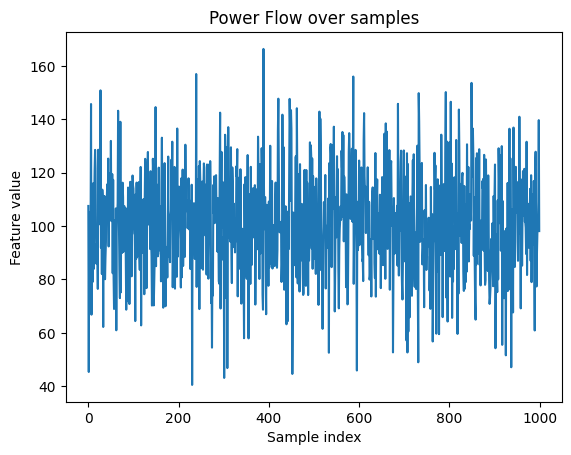

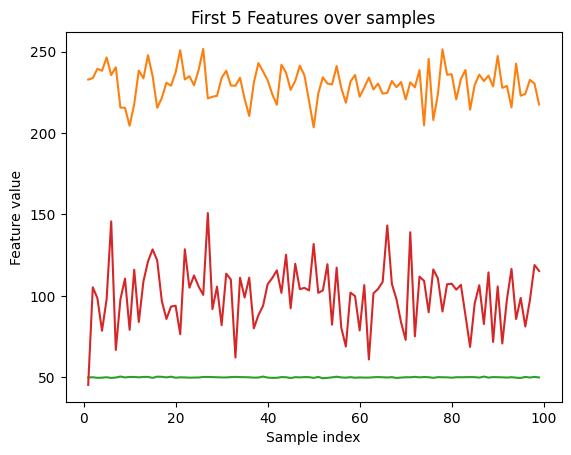

In [28]:
#Hvordan man plotter en feature? (Måske er det nydvendigt senere)
df_numeric = df.apply(pd.to_numeric, errors="coerce")

# Plot Specific features using regex to filter columns that match the pattern 'R1-PA[1-3]:VH'
plt.plot(df_numeric.filter(['power_flow']))
plt.xlabel("Sample index")
plt.ylabel("Feature value")
plt.title("Power Flow over samples")
plt.show()

# Plot features using iloc to select specific columns for the first 100 samples
plt.plot(df_numeric.iloc[1:100, 1:5])
plt.xlabel("Sample index")
plt.ylabel("Feature value")
plt.title("First 5 Features over samples")
plt.show()


# CNN Feature Extractor

- self.cnn = nn.Sequential()
    - order of inputs define which order each layer should execute in

- nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1)
    - in_channels : Number of input features, so how many variables are in each timestep
    - 32 : Output channels. How many patterns the CNN will learn.
    - Kernel_size : Size of the filter
    - Stride : how many steps we move the filter
    - padding : how many 0 we add to the start and end of the input. Prevents the sequence from shrinking too much. 

- nn.BatchNorm1d(32)
    - Normalizes the activations 
    
- nn.ReLU(inplace=True)
    - Means we are using relu
    - Inplace : modifys the current tensor directly, instead of creating a whole new tensor. This saves memory. 

- nn.MaxPool1d(2)
    - Reduce the sequence lenght by only keeping only the strongest activations
    - the 2, means that the seqence lenght is halved

In [106]:
class FeatureExtractor(nn.Module):
    def __init__(self, in_channels, d_model):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # reduce the sequence length by half

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2), 

            nn.Conv1d(128, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU()
        )
        
    def forward(self, x):
        return self.features(x)

# Classifier
This module implements the final classification head of the model. Its purpose is to thransform the feature representation produced by the FeatureExtractor into class logits.

The classifier takes a feature vectore and predicts the probability of each class.

- Flatten
    - Converts the input tensor into a 1-dimentional feature vector
- Linear Layer
    - Fully connected layer that learns combinations of the extracted features.
    - Reduces the feature dimension
- ReLU
    - Applies the non-linear function `f(x) = max(0, x)`
- Dropout
    - Randomly disables 20% of neurons during training.
    - Helps prevent overfitting by making the model rely on multiple features instead of a few dominant ones
- Linear Layer
    - Produces the final logits for each class.
    - For binary classification (`num_classes = 2`), the output shape becomes: `(batch_size, 2)`

In [107]:
class Classifier(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # single output for binary classification
        )

    def forward(self, x):
        return self.classifier(x)

# Positional Encoder

In [108]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        return x + self.pe[:, :x.size(1)]

# CNNTRansformer

- num_classes : Number of classes we want to classify prediction in. In our case it is binary (True / False)

- in_channels : Number of columns in dataset, or number of culumns the model should analyze. In our case it is all columns, expect for timestep. According to chat, we don't need timestep to make preidiction. 

- embed_dim : size of feature vector used by transformer. if training is unstable, reduce to 64, if model overfits, use 256. Embed_dim must be divisable by num_heads (FInd ud af specifikt h)

- num_heads : Number of attention heads in transformers mult-head attention layer. 

- num_layers : Number of transformer layers (?)

- mlp_dim : Size of feedforward inside each transformor layer (Hvorfor er det 256)

- dropout : Percentage of neurons we randomly turn off during each training step. 

In [109]:
class CNNTransformer(nn.Module):
    def __init__(self, in_channels, d_model, nhead, num_layers):
        super().__init__()
        
        self.feature_extractor = FeatureExtractor(in_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.2)
        self.transformer_encoder = nn.TransformerEncoder( encoder_layer, num_layers=num_layers)

        self.classifier = Classifier(d_model)

    def forward(self, x):
        # x: (batch_size, seq_len, in_channels)
        x = x.permute(0, 2, 1)                    # (batch_size, in_channels, seq_len)

        features = self.feature_extractor(x)      # (batch_size, d_model, seq_len//4)
        features = features.permute(0, 2, 1)      # (batch_size, seq_len//4, d_model)

        features = self.pos_encoder(features)      # add positional encoding
        transformer_out = self.transformer_encoder(features)   # (batch_size, seq_len//4, d_model)

        out = transformer_out.mean(dim=1)         # (batch_size, d_model)
        out = self.classifier(out)                # (batch_size, 1)

        return out.squeeze(-1)

# Train function

In [115]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

    return history

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for windows, labels in dataloader:
        windows = windows.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        logits = model(windows)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = windows.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct = 0

    with torch.no_grad():
        for windows, labels in dataloader:
            windows = windows.to(device)
            labels = labels.to(device).float()

            logits = model(windows)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            batch_size = windows.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            correct += (preds == labels).sum().item()

    return total_loss / total_samples, correct / total_samples

In [116]:
model = CNNTransformer(in_channels=IN_CHANNELS, d_model=128, nhead=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=nn.BCEWithLogitsLoss(),
    optimizer=optimizer,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    num_epochs=30
)
print(history)

Epoch 1/30 | Train Loss: 0.6979 | Test Loss: 0.6895 | Test Acc: 0.5630
Epoch 2/30 | Train Loss: 0.6761 | Test Loss: 0.6938 | Test Acc: 0.5630
Epoch 3/30 | Train Loss: 0.6623 | Test Loss: 0.6981 | Test Acc: 0.5378
Epoch 4/30 | Train Loss: 0.6407 | Test Loss: 0.7057 | Test Acc: 0.5126
Epoch 5/30 | Train Loss: 0.5975 | Test Loss: 0.7275 | Test Acc: 0.5294
Epoch 6/30 | Train Loss: 0.5455 | Test Loss: 0.7705 | Test Acc: 0.5042
Epoch 7/30 | Train Loss: 0.4697 | Test Loss: 0.8290 | Test Acc: 0.5042
Epoch 8/30 | Train Loss: 0.3859 | Test Loss: 0.9522 | Test Acc: 0.4706
Epoch 9/30 | Train Loss: 0.2821 | Test Loss: 1.0583 | Test Acc: 0.4958
Epoch 10/30 | Train Loss: 0.2174 | Test Loss: 1.2573 | Test Acc: 0.4538
Epoch 11/30 | Train Loss: 0.1274 | Test Loss: 1.4023 | Test Acc: 0.4454
Epoch 12/30 | Train Loss: 0.0987 | Test Loss: 1.5015 | Test Acc: 0.4706
Epoch 13/30 | Train Loss: 0.0831 | Test Loss: 1.6806 | Test Acc: 0.4538
Epoch 14/30 | Train Loss: 0.0515 | Test Loss: 1.8750 | Test Acc: 0.3950
E

# Transformer configuration 
- Config : Gets the  configuration of the pretrained model, in our case bert, which is from huggingface
- Model : generates the model from the configuration, initialized with randomized weights

The config, defines the following:
- hidden size : size of the vector used to represent each token inside the model. So the size of how many numbers should represent a token/word, and that becomes a vector. Must be divisible by number of heads. 

- number of layers : Number of transformer blocks stacked on top of eachother. Contains mult head layer connections. 12 layers. 

- number of attention heads : The amount of attention heads running in parralel. So each head would focus on different attention pattern (Long term relation, grammar, closely-related, etc.)

- intermediate size : hidden size of the feedforward network inside each tranformer network. Each layer has a small neural network. 
    - linear layer -> Activation function -> Linear layer
    - Often size = 4 * hidden size?

- dropout values : Regularization technique. Randomly turns of a percentage of random neurons. 

- vocabulary size : How many unqiue tokens a language knows. 

- positional embedding length : Defines maximum sequence length. So a model can only process at most x amount of tokens at once. Each position has a vector. For time series models this corresponds to max window size (sequence length).
    - final embedding = token embedding + positional embedding.


